# Dataset Export Verification
Checks that the exported GeoTIFF patches are structurally and visually correct.
- **Image**: 256×256, 14 bands (10 spectral + 4 indices)
- **Mask**: 256×256, 1 band, values in {1,2,3,4}, dominant class ≥ 60%

In [ ]:
import sys
!{sys.executable} -m pip install rasterio matplotlib numpy --quiet

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name == 'notebooks':
    PROJECT_DIR = PROJECT_DIR.parent

DATASET_DIR = PROJECT_DIR / 'data' / 'new_dataset'
IMG_PATH  = DATASET_DIR / 'cls1_s0_img.tif'
MASK_PATH = DATASET_DIR / 'cls1_s0_msk.tif'

BAND_NAMES = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12',
              'NDVI','NDWI','NDBI','MNDWI']

CLASS_NAMES = {1: 'Greenery', 2: 'Sand', 3: 'Water', 4: 'Cement'}
CLASS_COLORS = {1: '#2ecc71', 2: '#f39c12', 3: '#3498db', 4: '#95a5a6'}
DOMINANCE_THRESHOLD = 0.6
TARGET_CLASS = 1  # Greenery

print('Paths exist:', IMG_PATH.exists(), MASK_PATH.exists())

Paths exist: True True


## 1 Structural Checks

In [ ]:
PASS = '✅'
FAIL = '❌'

def check(label, condition, detail=''):
    status = PASS if condition else FAIL
    print(f'{status}  {label}' + (f'  →  {detail}' if detail else ''))
    return condition

results = []

# --- Image file ---
with rasterio.open(IMG_PATH) as src:
    img_shape  = (src.count, src.height, src.width)
    img_dtype  = src.dtypes[0]
    img_crs    = src.crs
    img_data   = src.read().astype(np.float32)

results.append(check('Image bands == 14',   img_shape[0] == 14,  f'got {img_shape[0]}'))
results.append(check('Image height == 256', img_shape[1] == 256, f'got {img_shape[1]}'))
results.append(check('Image width == 256',  img_shape[2] == 256, f'got {img_shape[2]}'))
results.append(check('Image dtype float32', img_dtype == 'float32', f'got {img_dtype}'))
results.append(check('Image has CRS',       img_crs is not None, str(img_crs)))

with rasterio.open(MASK_PATH) as src:
    msk_shape = (src.count, src.height, src.width)
    msk_dtype = src.dtypes[0]
    msk_data  = src.read(1)

results.append(check('Mask bands == 1',    msk_shape[0] == 1,   f'got {msk_shape[0]}'))
results.append(check('Mask height == 256', msk_shape[1] == 256, f'got {msk_shape[1]}'))
results.append(check('Mask width == 256',  msk_shape[2] == 256, f'got {msk_shape[2]}'))
results.append(check('Mask dtype uint8',   msk_dtype == 'uint8', f'got {msk_dtype}'))

unique_vals = np.unique(msk_data)
valid_vals  = set(unique_vals) - {0}  
results.append(check('Mask values ⊆ {1,2,3,4}', valid_vals.issubset({1,2,3,4}),
                      f'found {sorted(unique_vals)}'))

valid_pixels = msk_data[msk_data != 0]
total        = len(valid_pixels)
target_count = np.sum(valid_pixels == TARGET_CLASS)
dominance    = target_count / total if total > 0 else 0
results.append(check(f'Class {TARGET_CLASS} ({CLASS_NAMES[TARGET_CLASS]}) dominance ≥ {DOMINANCE_THRESHOLD:.0%}',
                     dominance >= DOMINANCE_THRESHOLD,
                     f'{dominance:.1%} of valid pixels'))

print(f'\nSummary: {sum(results)}/{len(results)} checks passed')

✅  Image bands == 14  →  got 14
✅  Image height == 256  →  got 256
✅  Image width == 256  →  got 256
✅  Image dtype float32  →  got float32
✅  Image has CRS  →  EPSG:4326
✅  Mask bands == 1  →  got 1
✅  Mask height == 256  →  got 256
✅  Mask width == 256  →  got 256
✅  Mask dtype uint8  →  got uint8
✅  Mask values ⊆ {1,2,3,4}  →  found [np.uint8(1), np.uint8(2), np.uint8(4)]
✅  Class 1 (Greenery) dominance ≥ 60%  →  99.9% of valid pixels

Summary: 11/11 checks passed


## 2 — Band Statistics

In [3]:
print(f'{"Band":<8} {"Min":>10} {"Max":>10} {"Mean":>10} {"Std":>10}  NaN?')
print('-' * 58)
for i, name in enumerate(BAND_NAMES):
    band = img_data[i]
    has_nan = np.isnan(band).any()
    print(f'{name:<8} {np.nanmin(band):>10.4f} {np.nanmax(band):>10.4f} '
          f'{np.nanmean(band):>10.4f} {np.nanstd(band):>10.4f}  {"yes" if has_nan else "no"}')

Band            Min        Max       Mean        Std  NaN?
----------------------------------------------------------
B2         222.0000  2259.0000   695.3190   328.8139  no
B3         424.5000  3061.0000  1135.1649   420.1376  no
B4         298.0000  4004.0000  1330.8445   651.6484  no
B5         850.0000  4079.5000  1909.9006   567.4918  no
B6        1941.5000  4603.5000  3021.2686   433.6815  no
B7        2331.5000  4932.0000  3433.8457   423.9057  no
B8        2230.0000  5130.5000  3584.9717   437.8452  no
B8A       2565.0000  5047.5000  3709.5220   403.4991  no
B11       1671.5000  5110.5000  3031.8611   689.6365  no
B12        887.5000  4456.0000  2244.2778   727.9648  no
NDVI         0.0593     0.8668     0.4811     0.1719  no
NDWI        -0.7392    -0.1604    -0.5293     0.1182  no
NDBI        -0.4221     0.2222    -0.0914     0.1049  no
MNDWI       -0.6625    -0.1785    -0.4670     0.0687  no


## 3 — Visual Inspection

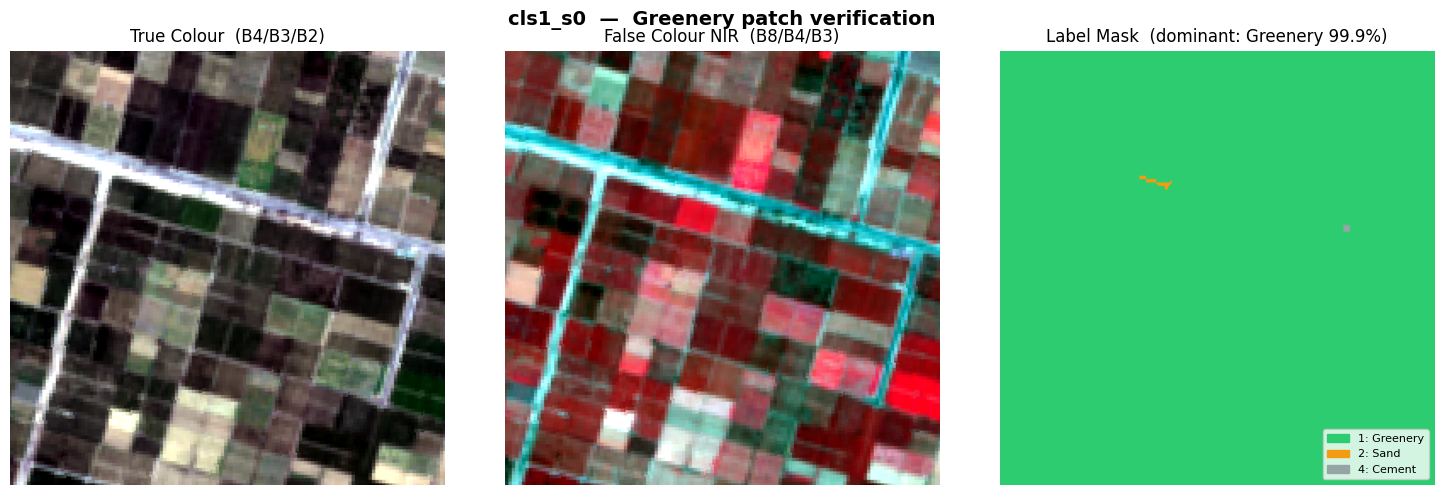

In [4]:
def normalise(arr):
    """Percentile stretch to [0,1] for display."""
    lo, hi = np.nanpercentile(arr, 2), np.nanpercentile(arr, 98)
    return np.clip((arr - lo) / (hi - lo + 1e-9), 0, 1)

# RGB: B4=band index 2, B3=band index 1, B2=band index 0
rgb = np.stack([normalise(img_data[2]),   # Red   (B4)
                normalise(img_data[1]),   # Green (B3)
                normalise(img_data[0])],  # Blue  (B2)
               axis=-1)

# False-colour NIR composite: B8=band index 6, B4=2, B3=1
nir = np.stack([normalise(img_data[6]),
                normalise(img_data[2]),
                normalise(img_data[1])],
               axis=-1)

# Colour-coded mask
mask_rgb = np.zeros((*msk_data.shape, 3), dtype=np.float32)
import matplotlib.colors as mcolors
for cls_id, hex_col in CLASS_COLORS.items():
    r, g, b = mcolors.to_rgb(hex_col)
    mask_rgb[msk_data == cls_id] = [r, g, b]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('cls1_s0  —  Greenery patch verification', fontsize=14, fontweight='bold')

axes[0].imshow(rgb)
axes[0].set_title('True Colour  (B4/B3/B2)')
axes[0].axis('off')

axes[1].imshow(nir)
axes[1].set_title('False Colour NIR  (B8/B4/B3)')
axes[1].axis('off')

axes[2].imshow(mask_rgb)
axes[2].set_title(f'Label Mask  (dominant: {CLASS_NAMES[TARGET_CLASS]} {dominance:.1%})')
axes[2].axis('off')
legend_patches = [mpatches.Patch(color=CLASS_COLORS[c], label=f'{c}: {CLASS_NAMES[c]}')
                  for c in CLASS_NAMES if c in valid_vals or c == TARGET_CLASS]
axes[2].legend(handles=legend_patches, loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

## 4 — Index Sanity Check

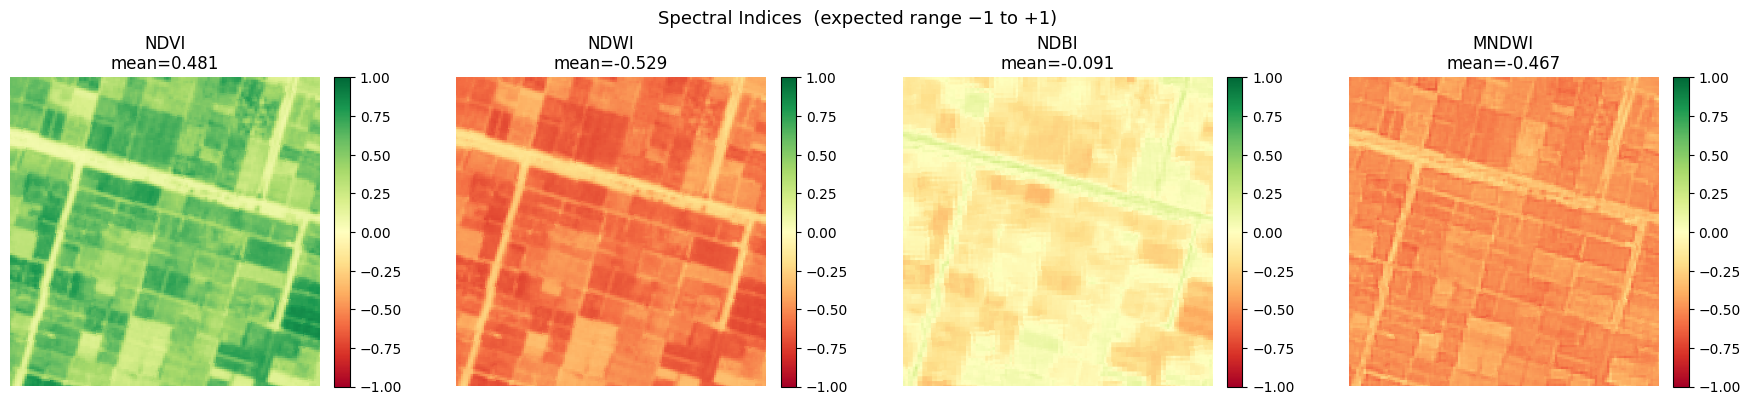

NDVI mean = 0.481  →  Good (vegetation dominant)


In [5]:
index_bands = {'NDVI': 10, 'NDWI': 11, 'NDBI': 12, 'MNDWI': 13}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, idx) in zip(axes, index_bands.items()):
    band = img_data[idx]
    im = ax.imshow(band, cmap='RdYlGn', vmin=-1, vmax=1)
    ax.set_title(f'{name}\nmean={np.nanmean(band):.3f}')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Spectral Indices  (expected range −1 to +1)', fontsize=13)
plt.tight_layout()
plt.show()

# For a Greenery patch: NDVI should be high (>0.3), NDBI/MNDWI should be low
ndvi_mean = np.nanmean(img_data[10])
print(f'NDVI mean = {ndvi_mean:.3f}  →  ', end='')
print('Good (vegetation dominant)' if ndvi_mean > 0.3 else 'Low – check class regions')